# What This Notebook Is

This notebook is a hands-on guide for understanding a small neural network built from scratch using Python and NumPy.

How to use it:
1. Read the cells in order.
2. Run each cell one by one.
3. Try to implement the forward pass and backward pass yourself before looking at the next step.
4. Use the project code in the package as a reference when you want to compare your understanding with the implementation.

If you want to truly learn the material, do not just copy the code. Try to reason through what each layer, loss, and update step is doing.

<div class="alert alert-block alert-warning">
Import the libraries needed for the examples and keep the notebook ready for the next steps.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mini_dl import *
from sklearn.model_selection import train_test_split

In [ ]:
# function to generate spiral data
def generate_spiral_data(n_points, n_classes):
    X = []
    y = []
    for class_number in range(n_classes):
        ix = range(n_points*class_number, n_points*(class_number+1))
        t = np.linspace(class_number*4, (class_number+1)*4, n_points) + np.random.randn(n_points)*0.2
        r = np.linspace(0, 1, n_points)
        X.extend(np.c_[r*np.sin(t), r*np.cos(t)])
        y.extend([class_number]*n_points)
    return np.array(X), np.array(y)

In [ ]:
# function to generate spiral data
def generate_spiral_data(n_points, n_classes):
    X = []
    y = []
    for class_number in range(n_classes):
        ix = range(n_points*class_number, n_points*(class_number+1))
        t = np.linspace(class_number*4, (class_number+1)*4, n_points) + np.random.randn(n_points)*0.2
        r = np.linspace(0, 1, n_points)
        X.extend(np.c_[r*np.sin(t), r*np.cos(t)])
        y.extend([class_number]*n_points)
    return np.array(X), np.array(y)

# Create dataset
X, y = generate_spiral_data(100, 3)

# Plot the spiral data
plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.title('Spiral Data')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

<div class="alert alert-block alert-warning">
<strong>Step 2 — Train a Simple Network</strong><br>
This cell builds a small network, runs a forward pass, computes the loss, and then performs backpropagation manually.
</div>

<div class="alert alert-block alert-warning">
<strong>Step 3 — Compare Optimizers</strong><br>
These cells show how the same network can be trained with different optimizer behavior such as decay and momentum.
</div>

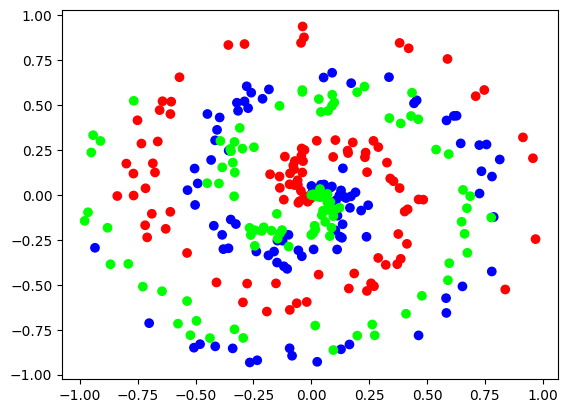

In [2]:
from nnfs.datasets import spiral_data
import numpy as np
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
X, y = spiral_data(samples=100, classes=3)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='brg')
plt.show()

In [30]:
# split into train test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False, random_state=42)

# dense layer with 2 input features and 64 outputs values
dense1 = Linear(2, 64)

# ReLU activation
activation1 = ReLU()

# dense layer with 64 input features and 3 outputs values
dense2 = Linear(64, 3)

# Softmax cross entrpy loss function for multi class classification
loss_activation = SoftmaxCrossEntropyLoss()

# Optimizer 
optimizer = SGD()
loss = []

for epoch in range(10001):
    # forward pass from each layer

    # forward pass of traning data from layer 1
    dense1.forward(X)

    # forward pass from activation layer
    # takes outputs of the dense1 layer 
    activation1.forward(dense1.outputs)

    # forward pass to second dense layer 
    # takes outputs of the activation function as input
    dense2.forward(activation1.outputs)

    # perform a forward pass through activation/loss function
    # takes outputs of the previous dense layer
    loss_activation.forward(dense2.outputs, y)
    loss.append(loss_activation.loss)

    # calculate accuracy from outputs of loss_activation and targets
    predictions = np.argmax(loss_activation.outputs, axis=1)
    if y.ndim==2:
        y = np.argmax(y, axis=1)
    accuracy=np.mean(predictions==y)
    if not epoch%100:
        print(f'epoch: {epoch}, '+
              f'acc: {accuracy:.3f}, '+
              f'loss: {loss_activation.loss:.3f} '+
              f'Lr: {optimizer.current_lr}')
    
    # Backward pass
    loss_activation.backward()
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # update parameters
    optimizer.step([dense1, dense2])

epoch: 0, acc: 0.377, loss: 1.100 Lr: 1.0
epoch: 100, acc: 0.453, loss: 1.056 Lr: 1.0
epoch: 200, acc: 0.460, loss: 1.043 Lr: 1.0
epoch: 300, acc: 0.440, loss: 1.039 Lr: 1.0
epoch: 400, acc: 0.463, loss: 1.035 Lr: 1.0
epoch: 500, acc: 0.480, loss: 1.016 Lr: 1.0
epoch: 600, acc: 0.513, loss: 1.025 Lr: 1.0
epoch: 700, acc: 0.500, loss: 1.020 Lr: 1.0
epoch: 800, acc: 0.487, loss: 1.008 Lr: 1.0
epoch: 900, acc: 0.527, loss: 0.998 Lr: 1.0
epoch: 1000, acc: 0.563, loss: 0.966 Lr: 1.0
epoch: 1100, acc: 0.550, loss: 0.969 Lr: 1.0
epoch: 1200, acc: 0.533, loss: 0.977 Lr: 1.0
epoch: 1300, acc: 0.557, loss: 0.947 Lr: 1.0
epoch: 1400, acc: 0.580, loss: 0.928 Lr: 1.0
epoch: 1500, acc: 0.560, loss: 0.939 Lr: 1.0
epoch: 1600, acc: 0.557, loss: 0.932 Lr: 1.0
epoch: 1700, acc: 0.583, loss: 0.940 Lr: 1.0
epoch: 1800, acc: 0.573, loss: 0.907 Lr: 1.0
epoch: 1900, acc: 0.580, loss: 0.911 Lr: 1.0
epoch: 2000, acc: 0.597, loss: 0.890 Lr: 1.0
epoch: 2100, acc: 0.613, loss: 0.863 Lr: 1.0
epoch: 2200, acc: 0.64

In [5]:
# using decay learning rate optimizer
# split into train test data
del dense1, dense2, activation1, loss_activation, optimizer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False, random_state=42)

# dense layer with 2 input features and 64 outputs values
dense1 = Linear(2, 64)

# ReLU activation
activation1 = ReLU()

# dense layer with 64 input features and 3 outputs values
dense2 = Linear(64, 3)

# Softmax cross entrpy loss function for multi class classification
loss_activation = SoftmaxCrossEntropyLoss()

# Optimizer 
optimizer = SGD(decay=1e-3)


for epoch in range(10001):
    # forward pass from each layer

    # forward pass of traning data from layer 1
    dense1.forward(X)

    # forward pass from activation layer
    # takes outputs of the dense1 layer 
    activation1.forward(dense1.outputs)

    # forward pass to second dense layer 
    # takes outputs of the activation function as input
    dense2.forward(activation1.outputs)

    # perform a forward pass through activation/loss function
    # takes outputs of the previous dense layer
    loss_activation.forward(dense2.outputs, y)

    # calculate accuracy from outputs of loss_activation and targets
    predictions = np.argmax(loss_activation.outputs, axis=1)
    if y.ndim==2:
        y = np.argmax(y, axis=1)
    accuracy=np.mean(predictions==y)
    if not epoch%100:
        print(f'epoch: {epoch}, '+
              f'acc: {accuracy:.3f}, '+
              f'loss: {loss_activation.loss:.3f} '+
              f'Lr: {optimizer.current_lr}')
    
    # Backward pass
    loss_activation.backward()
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # update parameters
    optimizer.step([dense1, dense2])
    

epoch: 0, acc: 0.270, loss: 1.219 Lr: 1.0
epoch: 100, acc: 0.450, loss: 1.050 Lr: 0.9099181073703367
epoch: 200, acc: 0.480, loss: 1.037 Lr: 0.8340283569641367
epoch: 300, acc: 0.487, loss: 1.025 Lr: 0.7698229407236336
epoch: 400, acc: 0.500, loss: 1.026 Lr: 0.7147962830593281
epoch: 500, acc: 0.497, loss: 1.020 Lr: 0.66711140760507
epoch: 600, acc: 0.493, loss: 1.025 Lr: 0.6253908692933083
epoch: 700, acc: 0.477, loss: 1.018 Lr: 0.5885815185403178
epoch: 800, acc: 0.510, loss: 1.008 Lr: 0.5558643690939411
epoch: 900, acc: 0.503, loss: 1.007 Lr: 0.526592943654555
epoch: 1000, acc: 0.507, loss: 0.982 Lr: 0.5002501250625312
epoch: 1100, acc: 0.507, loss: 0.980 Lr: 0.4764173415912339
epoch: 1200, acc: 0.553, loss: 0.975 Lr: 0.45475216007276037
epoch: 1300, acc: 0.553, loss: 0.971 Lr: 0.43497172683775553
epoch: 1400, acc: 0.530, loss: 0.966 Lr: 0.4168403501458941
epoch: 1500, acc: 0.587, loss: 0.943 Lr: 0.4001600640256102
epoch: 1600, acc: 0.567, loss: 0.945 Lr: 0.3847633705271258
epoch: 1

In [6]:
# using momentum
# split into train test data
del dense1, dense2, activation1, loss_activation, optimizer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False, random_state=42)

# dense layer with 2 input features and 64 outputs values
dense1 = Linear(2, 64)

# ReLU activation
activation1 = ReLU()

# dense layer with 64 input features and 3 outputs values
dense2 = Linear(64, 3)

# Softmax cross entrpy loss function for multi class classification
loss_activation = SoftmaxCrossEntropyLoss()

# Optimizer 
optimizer = SGD(decay=1e-3, momentum=0.9)


for epoch in range(10001):
    # forward pass from each layer

    # forward pass of traning data from layer 1
    dense1.forward(X)

    # forward pass from activation layer
    # takes outputs of the dense1 layer 
    activation1.forward(dense1.outputs)

    # forward pass to second dense layer 
    # takes outputs of the activation function as input
    dense2.forward(activation1.outputs)

    # perform a forward pass through activation/loss function
    # takes outputs of the previous dense layer
    loss_activation.forward(dense2.outputs, y)

    # calculate accuracy from outputs of loss_activation and targets
    predictions = np.argmax(loss_activation.outputs, axis=1)
    if y.ndim==2:
        y = np.argmax(y, axis=1)
    accuracy=np.mean(predictions==y)
    if not epoch%100:
        print(f'epoch: {epoch}, '+
              f'acc: {accuracy:.3f}, '+
              f'loss: {loss_activation.loss:.3f} '+
              f'Lr: {optimizer.current_lr}')
    
    # Backward pass
    loss_activation.backward()
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # update parameters
    optimizer.step([dense1, dense2])

epoch: 0, acc: 0.303, loss: 1.200 Lr: 1.0
epoch: 100, acc: 0.633, loss: 0.833 Lr: 0.9099181073703367
epoch: 200, acc: 0.627, loss: 0.764 Lr: 0.8340283569641367
epoch: 300, acc: 0.840, loss: 0.431 Lr: 0.7698229407236336
epoch: 400, acc: 0.880, loss: 0.318 Lr: 0.7147962830593281
epoch: 500, acc: 0.893, loss: 0.275 Lr: 0.66711140760507
epoch: 600, acc: 0.917, loss: 0.227 Lr: 0.6253908692933083
epoch: 700, acc: 0.920, loss: 0.207 Lr: 0.5885815185403178
epoch: 800, acc: 0.923, loss: 0.192 Lr: 0.5558643690939411
epoch: 900, acc: 0.927, loss: 0.182 Lr: 0.526592943654555
epoch: 1000, acc: 0.933, loss: 0.174 Lr: 0.5002501250625312
epoch: 1100, acc: 0.933, loss: 0.168 Lr: 0.4764173415912339
epoch: 1200, acc: 0.940, loss: 0.160 Lr: 0.45475216007276037
epoch: 1300, acc: 0.943, loss: 0.155 Lr: 0.43497172683775553
epoch: 1400, acc: 0.943, loss: 0.150 Lr: 0.4168403501458941
epoch: 1500, acc: 0.943, loss: 0.146 Lr: 0.4001600640256102
epoch: 1600, acc: 0.947, loss: 0.143 Lr: 0.3847633705271258
epoch: 1

In [4]:
# using adagrad
# split into train test data
from mini_dl.optimizer_.sgd import Optimizer_adagrad


#del dense1, dense2, activation1, loss_activation, optimizer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False, random_state=42)

# dense layer with 2 input features and 64 outputs values
dense1 = Linear(2, 64)

# ReLU activation
activation1 = ReLU()

# dense layer with 64 input features and 3 outputs values
dense2 = Linear(64, 3)

# Softmax cross entrpy loss function for multi class classification
loss_activation = SoftmaxCrossEntropyLoss()

# Optimizer 
optimizer = Optimizer_adagrad(decay=1e-3)


for epoch in range(15001):
    # forward pass from each layer

    # forward pass of traning data from layer 1
    dense1.forward(X)

    # forward pass from activation layer
    # takes outputs of the dense1 layer 
    activation1.forward(dense1.outputs)

    # forward pass to second dense layer 
    # takes outputs of the activation function as input
    dense2.forward(activation1.outputs)

    # perform a forward pass through activation/loss function
    # takes outputs of the previous dense layer
    loss_activation.forward(dense2.outputs, y)

    # calculate accuracy from outputs of loss_activation and targets
    predictions = np.argmax(loss_activation.outputs, axis=1)
    if y.ndim==2:
        y = np.argmax(y, axis=1)
    accuracy=np.mean(predictions==y)
    if not epoch%100:
        print(f'epoch: {epoch}, '+
              f'acc: {accuracy:.3f}, '+
              f'loss: {loss_activation.loss:.3f} '+
              f'Lr: {optimizer.current_lr}')
    
    # Backward pass
    loss_activation.backward()
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # update parameters
    optimizer.step([dense1, dense2])

epoch: 0, acc: 0.410, loss: 1.374 Lr: 1.0
epoch: 100, acc: 0.473, loss: 1.014 Lr: 0.9099181073703367
epoch: 200, acc: 0.553, loss: 0.956 Lr: 0.8340283569641367
epoch: 300, acc: 0.590, loss: 0.896 Lr: 0.7698229407236336
epoch: 400, acc: 0.610, loss: 0.848 Lr: 0.7147962830593281
epoch: 500, acc: 0.630, loss: 0.813 Lr: 0.66711140760507
epoch: 600, acc: 0.643, loss: 0.793 Lr: 0.6253908692933083
epoch: 700, acc: 0.660, loss: 0.778 Lr: 0.5885815185403178
epoch: 800, acc: 0.660, loss: 0.767 Lr: 0.5558643690939411
epoch: 900, acc: 0.667, loss: 0.759 Lr: 0.526592943654555
epoch: 1000, acc: 0.677, loss: 0.751 Lr: 0.5002501250625312
epoch: 1100, acc: 0.677, loss: 0.745 Lr: 0.4764173415912339
epoch: 1200, acc: 0.687, loss: 0.740 Lr: 0.45475216007276037
epoch: 1300, acc: 0.687, loss: 0.735 Lr: 0.43497172683775553
epoch: 1400, acc: 0.687, loss: 0.730 Lr: 0.4168403501458941
epoch: 1500, acc: 0.687, loss: 0.726 Lr: 0.4001600640256102
epoch: 1600, acc: 0.690, loss: 0.722 Lr: 0.3847633705271258
epoch: 1

In [7]:
# using RMS prop optimizer
# split into train test data
from mini_dl.optimizer_.sgd import Optimizer_adagrad, RMSProp


#del dense1, dense2, activation1, loss_activation, optimizer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, shuffle=False, random_state=42)

# dense layer with 2 input features and 64 outputs values
dense1 = Linear(2, 64)

# ReLU activation
activation1 = ReLU()

# dense layer with 64 input features and 3 outputs values
dense2 = Linear(64, 3)

# Softmax cross entrpy loss function for multi class classification
loss_activation = SoftmaxCrossEntropyLoss()

# Optimizer 
optimizer = RMSProp(learning_rate=0.03, decay=1e-2, rho=0.9)


for epoch in range(15001):
    # forward pass from each layer

    # forward pass of traning data from layer 1
    dense1.forward(X)

    # forward pass from activation layer
    # takes outputs of the dense1 layer 
    activation1.forward(dense1.outputs)

    # forward pass to second dense layer 
    # takes outputs of the activation function as input
    dense2.forward(activation1.outputs)

    # perform a forward pass through activation/loss function
    # takes outputs of the previous dense layer
    loss_activation.forward(dense2.outputs, y)

    # calculate accuracy from outputs of loss_activation and targets
    predictions = np.argmax(loss_activation.outputs, axis=1)
    if y.ndim==2:
        y = np.argmax(y, axis=1)
    accuracy=np.mean(predictions==y)
    if not epoch%100:
        print(f'epoch: {epoch}, '+
              f'acc: {accuracy:.3f}, '+
              f'loss: {loss_activation.loss:.3f} '+
              f'Lr: {optimizer.current_lr}')
    
    # Backward pass
    loss_activation.backward()
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # update parameters
    optimizer.step([dense1, dense2])

epoch: 0, acc: 0.307, loss: 1.161 Lr: 0.03
epoch: 100, acc: 0.507, loss: 1.008 Lr: 0.015075376884422108
epoch: 200, acc: 0.600, loss: 0.954 Lr: 0.010033444816053512
epoch: 300, acc: 0.600, loss: 0.917 Lr: 0.007518796992481203
epoch: 400, acc: 0.650, loss: 0.887 Lr: 0.0060120240480961915
epoch: 500, acc: 0.643, loss: 0.859 Lr: 0.005008347245409015
epoch: 600, acc: 0.670, loss: 0.835 Lr: 0.004291845493562231
epoch: 700, acc: 0.663, loss: 0.814 Lr: 0.0037546933667083854
epoch: 800, acc: 0.677, loss: 0.796 Lr: 0.003337041156840934
epoch: 900, acc: 0.663, loss: 0.781 Lr: 0.0030030030030030025
epoch: 1000, acc: 0.680, loss: 0.767 Lr: 0.0027297543221110098
epoch: 1100, acc: 0.683, loss: 0.754 Lr: 0.0025020850708924102
epoch: 1200, acc: 0.683, loss: 0.743 Lr: 0.0023094688221709007
epoch: 1300, acc: 0.683, loss: 0.732 Lr: 0.002144388849177984
epoch: 1400, acc: 0.707, loss: 0.719 Lr: 0.0020013342228152103
epoch: 1500, acc: 0.727, loss: 0.708 Lr: 0.0018761726078799247
epoch: 1600, acc: 0.733, los

In [23]:
# using adam optimizer
# split into train test data
from mini_dl.optimizer_.sgd import Optimizer_adagrad, RMSProp, Optimizer_Adam


# del dense1, dense2, activation1, loss_activation, optimizer
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# dense layer with 2 input features and 64 outputs values
dense1 = Linear(2, 64)

# ReLU activation
activation1 = ReLU()

# dense layer with 64 input features and 3 outputs values
dense2 = Linear(64, 3)

# Softmax cross entrpy loss function for multi class classification
loss_activation = SoftmaxCrossEntropyLoss()

# Optimizer 
optimizer = Optimizer_Adam(learning_rate=0.01, decay=1e-3)
loss = []


for epoch in range(15001):
    # forward pass from each layer

    # forward pass of traning data from layer 1
    dense1.forward(X_train)

    # forward pass from activation layer
    # takes outputs of the dense1 layer 
    activation1.forward(dense1.outputs)

    # forward pass to second dense layer 
    # takes outputs of the activation function as input
    dense2.forward(activation1.outputs)

    # perform a forward pass through activation/loss function
    # takes outputs of the previous dense layer
    loss_activation.forward(dense2.outputs, y_train)

    # calculate accuracy from outputs of loss_activation and targets
    predictions = np.argmax(loss_activation.outputs, axis=1)
    loss.append(loss_activation.loss)
    if y_train.ndim==2:
        y_train = np.argmax(y_train, axis=1)
    accuracy=np.mean(predictions==y_train)
    if not epoch%100:
        print(f'epoch: {epoch}, '+
              f'acc: {accuracy:.3f}, '+
              f'loss: {loss_activation.loss:.3f} '+
              f'Lr: {optimizer.current_lr}')
    
    # Backward pass
    loss_activation.backward()
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # update parameters
    optimizer.step([dense1, dense2])

epoch: 0, acc: 0.404, loss: 1.151 Lr: 0.01
epoch: 100, acc: 0.512, loss: 0.978 Lr: 0.00909090909090909
epoch: 200, acc: 0.683, loss: 0.831 Lr: 0.008333333333333333
epoch: 300, acc: 0.721, loss: 0.716 Lr: 0.007692307692307692
epoch: 400, acc: 0.754, loss: 0.627 Lr: 0.0071428571428571435
epoch: 500, acc: 0.796, loss: 0.555 Lr: 0.006666666666666666
epoch: 600, acc: 0.804, loss: 0.498 Lr: 0.00625
epoch: 700, acc: 0.817, loss: 0.449 Lr: 0.00588235294117647
epoch: 800, acc: 0.838, loss: 0.408 Lr: 0.005555555555555556
epoch: 900, acc: 0.854, loss: 0.372 Lr: 0.005263157894736842
epoch: 1000, acc: 0.879, loss: 0.345 Lr: 0.005
epoch: 1100, acc: 0.887, loss: 0.323 Lr: 0.0047619047619047615
epoch: 1200, acc: 0.896, loss: 0.305 Lr: 0.004545454545454545
epoch: 1300, acc: 0.896, loss: 0.286 Lr: 0.004347826086956523
epoch: 1400, acc: 0.892, loss: 0.272 Lr: 0.004166666666666667
epoch: 1500, acc: 0.912, loss: 0.260 Lr: 0.004
epoch: 1600, acc: 0.921, loss: 0.248 Lr: 0.003846153846153846
epoch: 1700, acc:

In [24]:
# Forward pass on test data
dense1.forward(X_test)
activation1.forward(dense1.outputs)
dense2.forward(activation1.outputs)
loss_activation.forward(dense2.outputs, y_test)

predictions = np.argmax(loss_activation.outputs, axis=1)
test_accuracy = (predictions == y_test).astype(int)

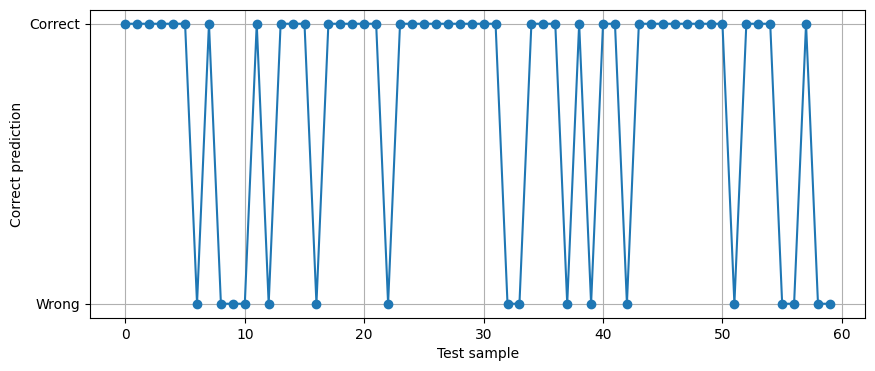

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(test_accuracy, marker='o')
plt.xlabel("Test sample")
plt.ylabel("Correct prediction")
plt.yticks([0, 1], ["Wrong", "Correct"])
plt.grid(True)
plt.show()

In [6]:
# using softmax cross-entropy for multiclass classification
from mini_dl.optimizer_.sgd import Optimizer_adagrad, RMSProp, Optimizer_Adam

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# convert targets to class indices once
if y_train.ndim == 2:
    y_train_targets = np.argmax(y_train, axis=1)
else:
    y_train_targets = y_train

# dense layer with 2 input features and 64 outputs values
dense1 = Linear(2, 64)

# ReLU activation
activation1 = ReLU()

# dense layer with 64 input features and 3 outputs values
dense2 = Linear(64, 3)

# Softmax cross entropy loss function for multi-class classification
loss_activation = SoftmaxCrossEntropyLoss()

# Optimizer
optimizer = Optimizer_Adam(learning_rate=0.01, decay=1e-3)
loss_history = []

for epoch in range(15001):
    # forward pass from each layer
    dense1.forward(X_train)
    activation1.forward(dense1.outputs)
    dense2.forward(activation1.outputs)

    # perform a forward pass through activation/loss function
    loss_activation.forward(
        dense2.outputs,
        y_train_targets,
        regularization_layers=[dense1, dense2],
        l1=0.0,
        l2=1e-5,
    )
    loss_history.append(loss_activation.loss)

    predictions = np.argmax(loss_activation.outputs, axis=1)
    accuracy = np.mean(predictions == y_train_targets)

    if not epoch % 100:
        print(
            f"epoch: {epoch}, "
            f"acc: {accuracy:.3f}, "
            f"loss: {loss_activation.loss:.3f} "
            f"Lr: {optimizer.current_lr}"
        )

    # backward pass
    loss_activation.backward()
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    # update parameters
    optimizer.step([dense1, dense2])


epoch: 0, acc: 0.312, loss: 1.201 Lr: 0.01
epoch: 100, acc: 0.438, loss: 1.009 Lr: 0.00909090909090909
epoch: 200, acc: 0.646, loss: 0.868 Lr: 0.008333333333333333
epoch: 300, acc: 0.700, loss: 0.740 Lr: 0.007692307692307692
epoch: 400, acc: 0.746, loss: 0.620 Lr: 0.0071428571428571435
epoch: 500, acc: 0.821, loss: 0.534 Lr: 0.006666666666666666
epoch: 600, acc: 0.846, loss: 0.476 Lr: 0.00625
epoch: 700, acc: 0.863, loss: 0.433 Lr: 0.00588235294117647
epoch: 800, acc: 0.879, loss: 0.396 Lr: 0.005555555555555556
epoch: 900, acc: 0.879, loss: 0.365 Lr: 0.005263157894736842
epoch: 1000, acc: 0.883, loss: 0.330 Lr: 0.005
epoch: 1100, acc: 0.892, loss: 0.310 Lr: 0.0047619047619047615
epoch: 1200, acc: 0.904, loss: 0.294 Lr: 0.004545454545454545
epoch: 1300, acc: 0.917, loss: 0.281 Lr: 0.004347826086956523
epoch: 1400, acc: 0.912, loss: 0.270 Lr: 0.004166666666666667
epoch: 1500, acc: 0.912, loss: 0.260 Lr: 0.004
epoch: 1600, acc: 0.921, loss: 0.253 Lr: 0.003846153846153846
epoch: 1700, acc:

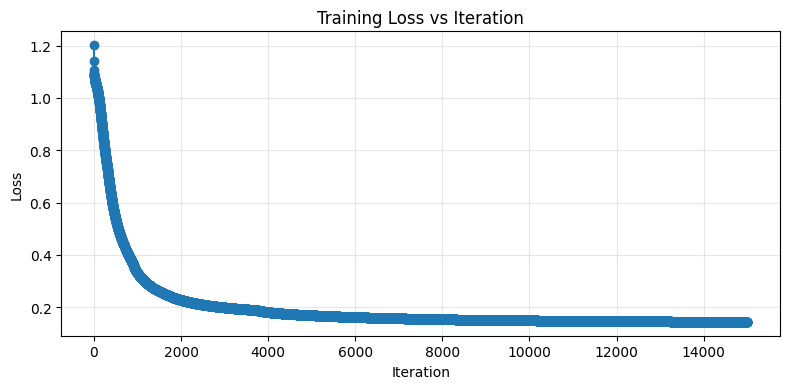

In [54]:
# Checking if the loss have sudden peak regions which might indicate that the model is overfitted to the underlying data

# You can run the above different 
import matplotlib.pyplot as plt

# Example: losses is a list of loss values
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker='o', linewidth=1.5)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Training Loss vs Iteration")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
# Forward pass on test data
dense1.forward(X_test)
activation1.forward(dense1.outputs)
dense2.forward(activation1.outputs)
loss_activation.forward(dense2.outputs, y_test)

predictions = np.argmax(loss_activation.outputs, axis=1)
test_accuracy = (predictions == y_test).astype(int)

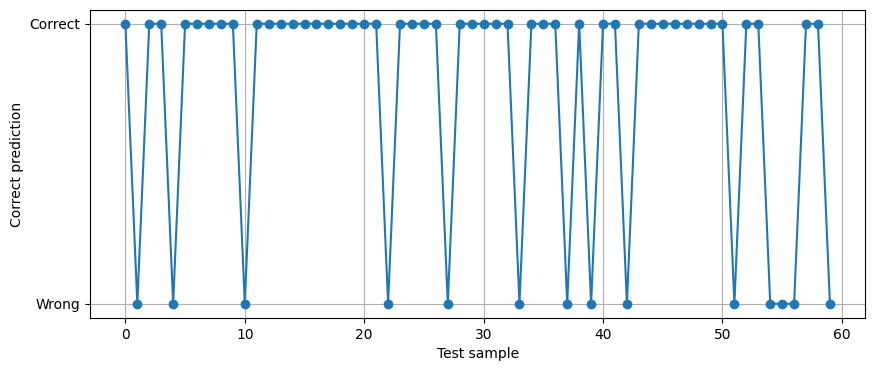

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(test_accuracy, marker='o')
plt.xlabel("Test sample")
plt.ylabel("Correct prediction")
plt.yticks([0, 1], ["Wrong", "Correct"])
plt.grid(True)
plt.show()

In [10]:
np.mean(predictions == y_test)

np.float64(0.7666666666666667)

In [30]:
np.random.binomial(1, 0.85, size=10)

array([1, 1, 0, 1, 1, 1, 1, 1, 1, 0])